In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
# Reload the dataframe to ensure it's available
df = pd.read_csv('mt_vs_st.csv')
print("Dataframe loaded successfully!")
print(df.head())

Dataframe loaded successfully!
        ENDPOINT    TPMT    TNMT    FPMT    FNMT    TPST    TNST    FPST  \
0          NR-AR  0.3235  0.9986  0.0014  0.6765  0.4118  1.0000  0.0000   
1   NR-Aromatase  0.2432  0.9927  0.0073  0.7568  0.2973  0.9872  0.0128   
2  NR-PPAR-gamma  0.0625  0.9953  0.0047  0.9375  0.1875  0.9984  0.0016   
3         SR-HSE  0.1750  0.9967  0.0033  0.8250  0.2000  0.9951  0.0049   
4      NR-AR-LBD  0.3913  0.9955  0.0045  0.6087  0.5217  0.9955  0.0045   

     FNST  
0  0.5882  
1  0.7027  
2  0.8125  
3  0.8000  
4  0.4783  


In [8]:
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

print("\nTrue Positive (TP) Rate:")
print(f"  MTDNN mean: {df['TPMT'].mean():.4f} ± {df['TPMT'].std():.4f}")
print(f"  STDNN mean: {df['TPST'].mean():.4f} ± {df['TPST'].std():.4f}")
print(f"  Difference: {(df['TPMT'].mean() - df['TPST'].mean()):.4f}")

print("\nFalse Positive (FP) Rate:")
print(f"  MTDNN mean: {df['FPMT'].mean():.4f} ± {df['FPMT'].std():.4f}")
print(f"  STDNN mean: {df['FPST'].mean():.4f} ± {df['FPST'].std():.4f}")
print(f"  Difference: {(df['FPMT'].mean() - df['FPST'].mean()):.4f}")

print("\nTrue Negative (TN) Rate:")
print(f"  MTDNN mean: {df['TNMT'].mean():.4f} ± {df['TNMT'].std():.4f}")
print(f"  STDNN mean: {df['TNST'].mean():.4f} ± {df['TNST'].std():.4f}")
print(f"  Difference: {(df['TNMT'].mean() - df['TNST'].mean()):.4f}")

print("\nFalse Negative (FN) Rate:")
print(f"  MTDNN mean: {df['FNMT'].mean():.4f} ± {df['FNMT'].std():.4f}")
print(f"  STDNN mean: {df['FNST'].mean():.4f} ± {df['FNST'].std():.4f}")
print(f"  Difference: {(df['FNMT'].mean() - df['FNST'].mean()):.4f}")

print("\n" + "=" * 70)

SUMMARY STATISTICS

True Positive (TP) Rate:
  MTDNN mean: 0.2880 ± 0.1254
  STDNN mean: 0.3405 ± 0.1366
  Difference: -0.0525

False Positive (FP) Rate:
  MTDNN mean: 0.0146 ± 0.0145
  STDNN mean: 0.0165 ± 0.0179
  Difference: -0.0018

True Negative (TN) Rate:
  MTDNN mean: 0.9854 ± 0.0145
  STDNN mean: 0.9836 ± 0.0179
  Difference: 0.0018

False Negative (FN) Rate:
  MTDNN mean: 0.7121 ± 0.1254
  STDNN mean: 0.6595 ± 0.1366
  Difference: 0.0525



## Summary Statistics

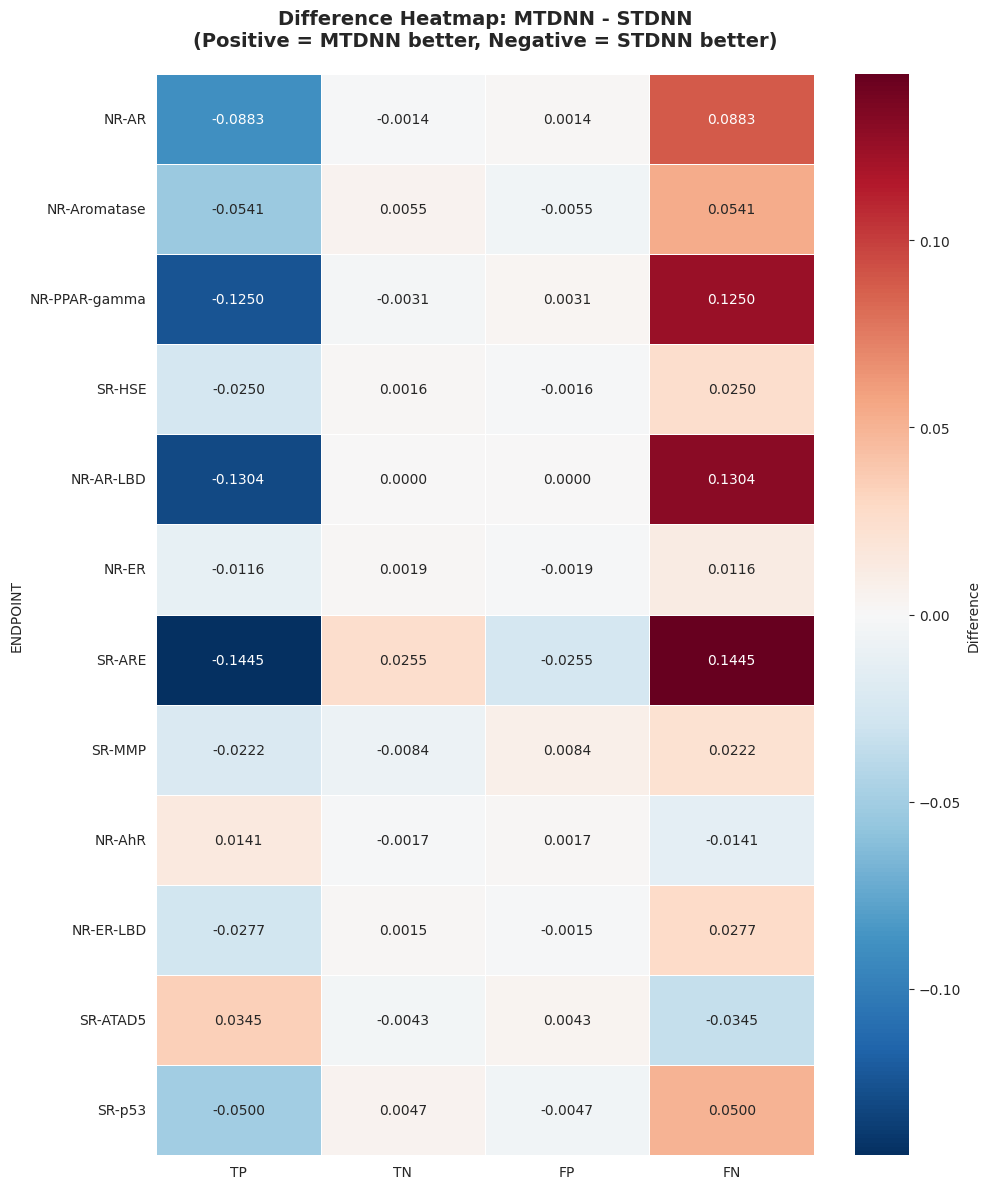

In [9]:
import seaborn as sns
# Calculate differences
df['TP_diff'] = df['TPMT'] - df['TPST']
df['TN_diff'] = df['TNMT'] - df['TNST']
df['FP_diff'] = df['FPMT'] - df['FPST']
df['FN_diff'] = df['FNMT'] - df['FNST']

# Create heatmap for differences
diff_data = df[['ENDPOINT', 'TP_diff', 'TN_diff', 'FP_diff', 'FN_diff']].set_index('ENDPOINT')
diff_data = diff_data.rename(columns={'TP_diff': 'TP', 'TN_diff': 'TN', 'FP_diff': 'FP', 'FN_diff': 'FN'})

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(diff_data, annot=True, fmt='.4f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Difference'}, ax=ax,
            linewidths=0.5)
ax.set_title('Difference Heatmap: MTDNN - STDNN\n(Positive = MTDNN better, Negative = STDNN better)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Difference Analysis (MT - ST)

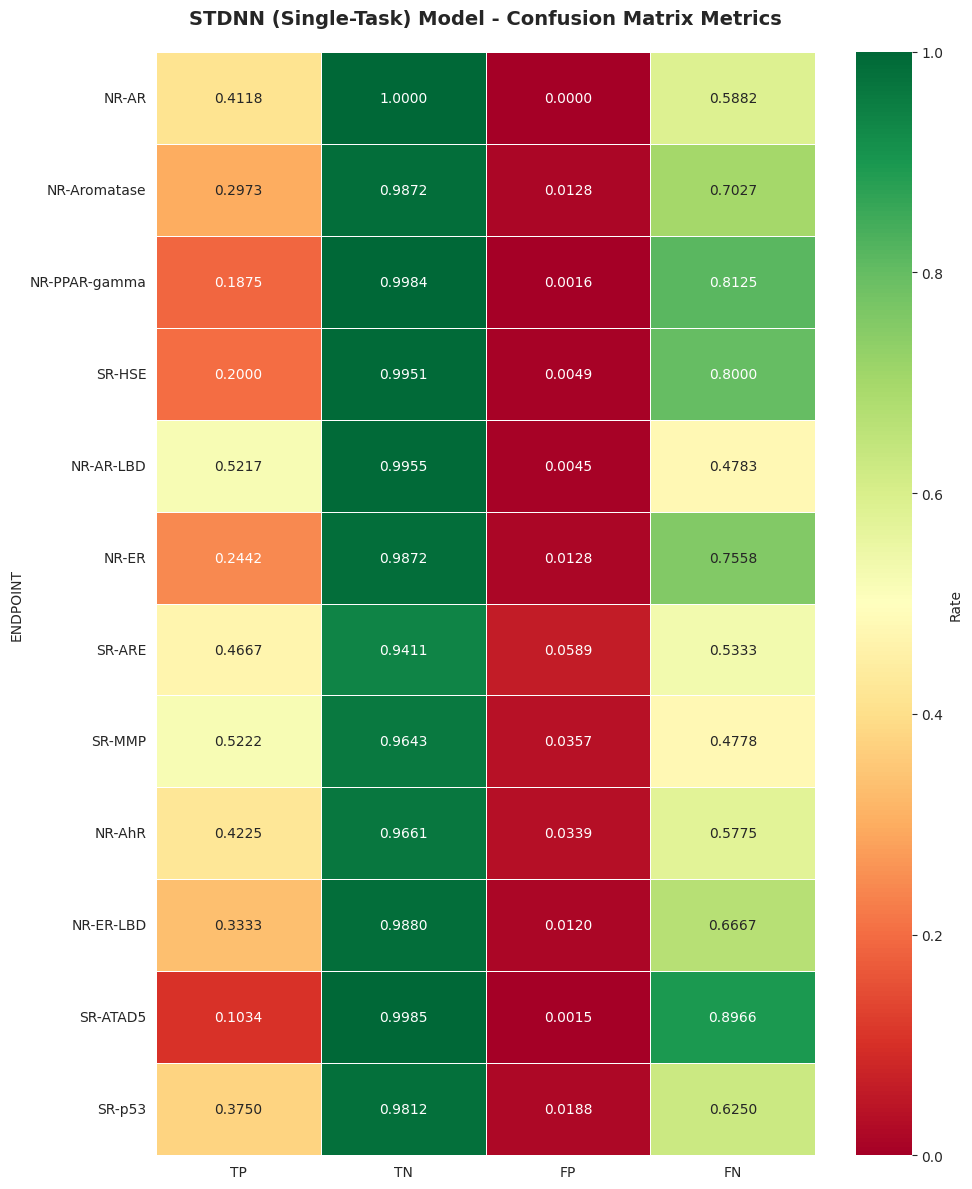

In [10]:
# Create heatmap for STDNN (ST) results
st_data = df[['ENDPOINT', 'TPST', 'TNST', 'FPST', 'FNST']].set_index('ENDPOINT')
st_data = st_data.rename(columns={'TPST': 'TP', 'TNST': 'TN', 'FPST': 'FP', 'FNST': 'FN'})

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(st_data, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Rate'}, ax=ax,
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('STDNN (Single-Task) Model - Confusion Matrix Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

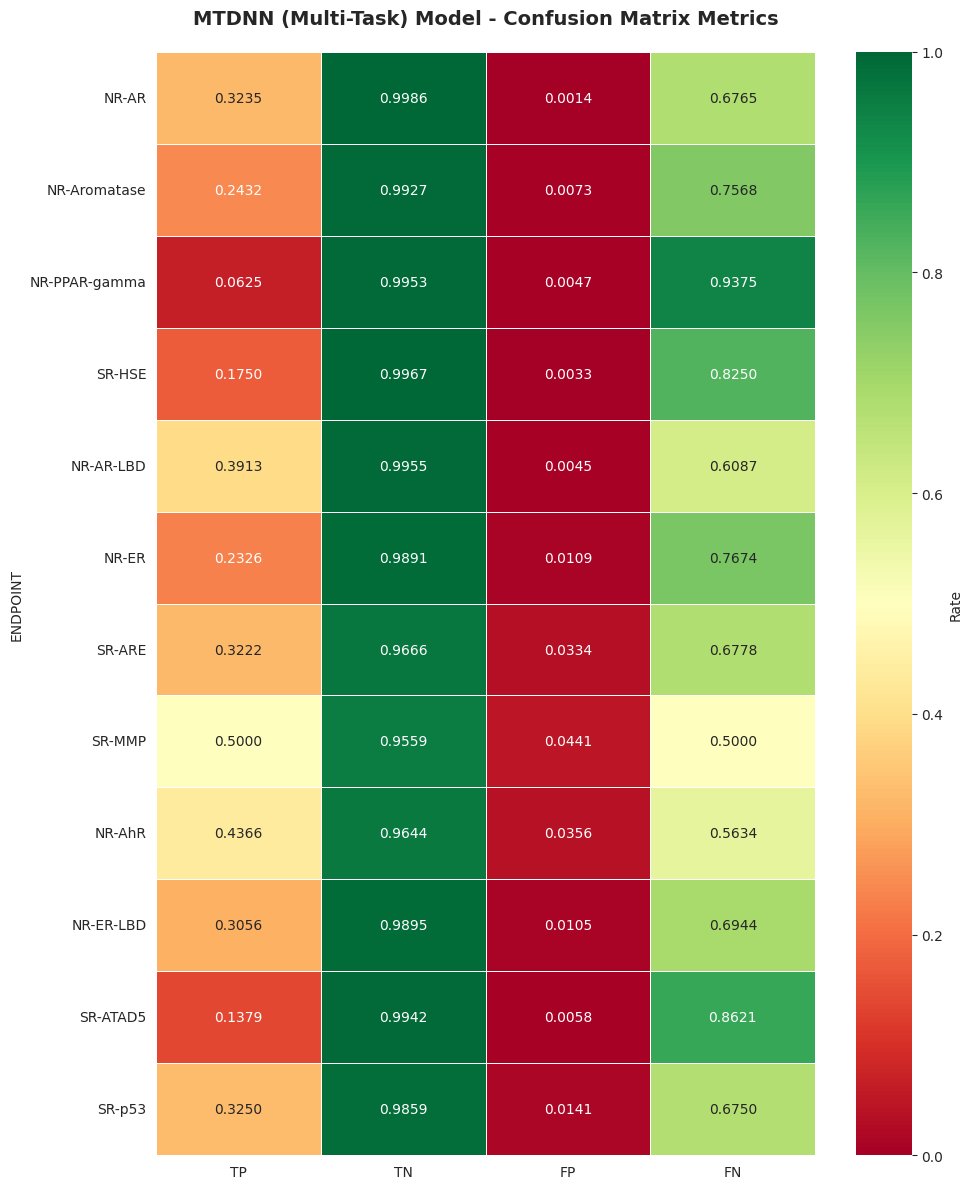

In [11]:
# Create heatmap for MTDNN (MT) results
mt_data = df[['ENDPOINT', 'TPMT', 'TNMT', 'FPMT', 'FNMT']].set_index('ENDPOINT')
mt_data = mt_data.rename(columns={'TPMT': 'TP', 'TNMT': 'TN', 'FPMT': 'FP', 'FNMT': 'FN'})

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(mt_data, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'Rate'}, ax=ax, 
            vmin=0, vmax=1, linewidths=0.5)
ax.set_title('MTDNN (Multi-Task) Model - Confusion Matrix Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Heatmaps of Confusion Matrix Metrics

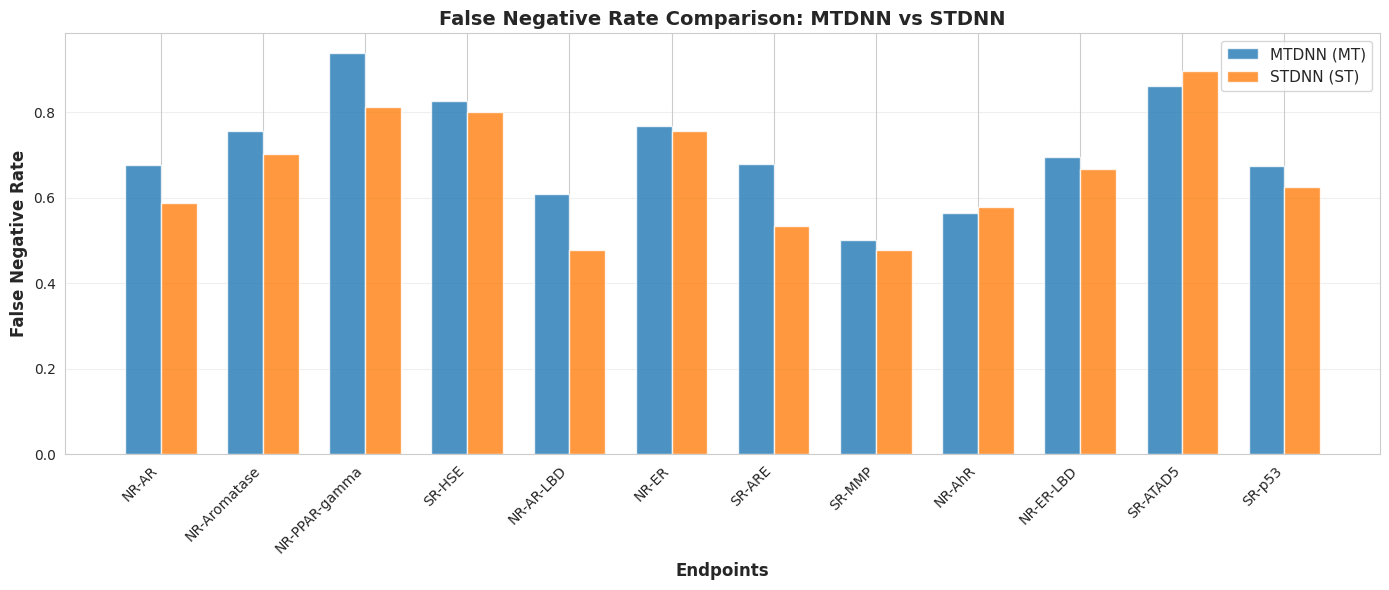

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df['FNMT'], width, label='MTDNN (MT)', alpha=0.8)
bars2 = ax.bar(x + width/2, df['FNST'], width, label='STDNN (ST)', alpha=0.8)

ax.set_xlabel('Endpoints', fontsize=12, fontweight='bold')
ax.set_ylabel('False Negative Rate', fontsize=12, fontweight='bold')
ax.set_title('False Negative Rate Comparison: MTDNN vs STDNN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['ENDPOINT'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison of False Negative Rates (FN)

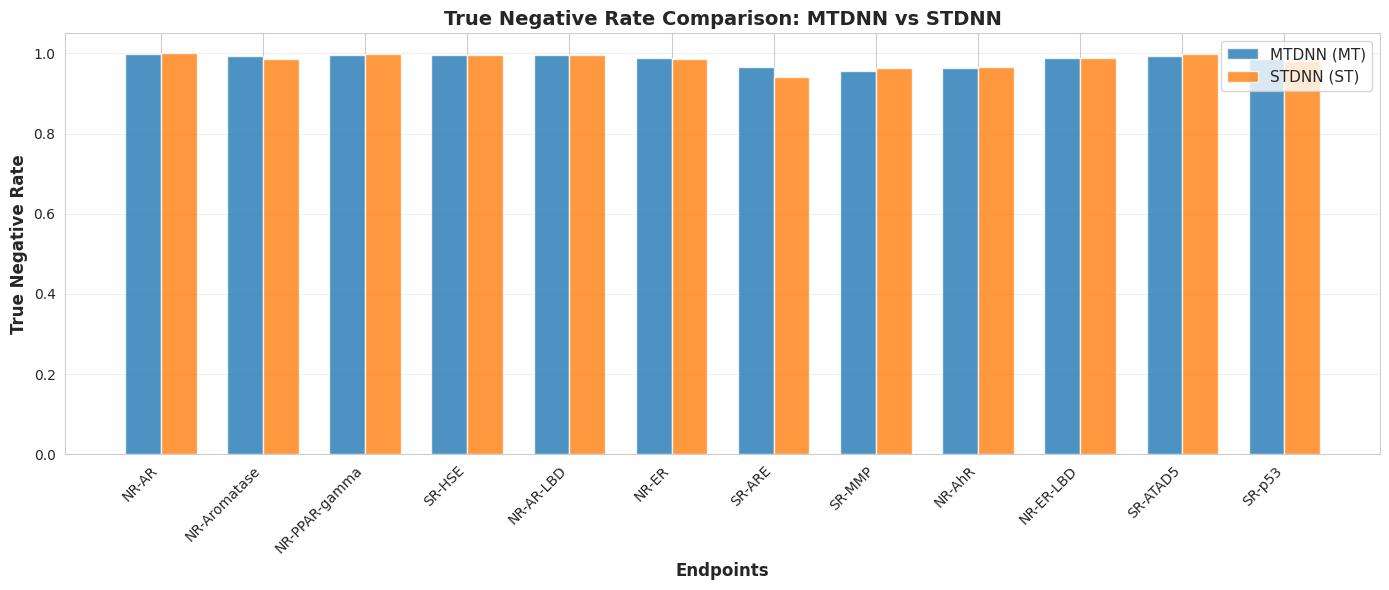

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df['TNMT'], width, label='MTDNN (MT)', alpha=0.8)
bars2 = ax.bar(x + width/2, df['TNST'], width, label='STDNN (ST)', alpha=0.8)

ax.set_xlabel('Endpoints', fontsize=12, fontweight='bold')
ax.set_ylabel('True Negative Rate', fontsize=12, fontweight='bold')
ax.set_title('True Negative Rate Comparison: MTDNN vs STDNN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['ENDPOINT'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison of True Negative Rates (TN)

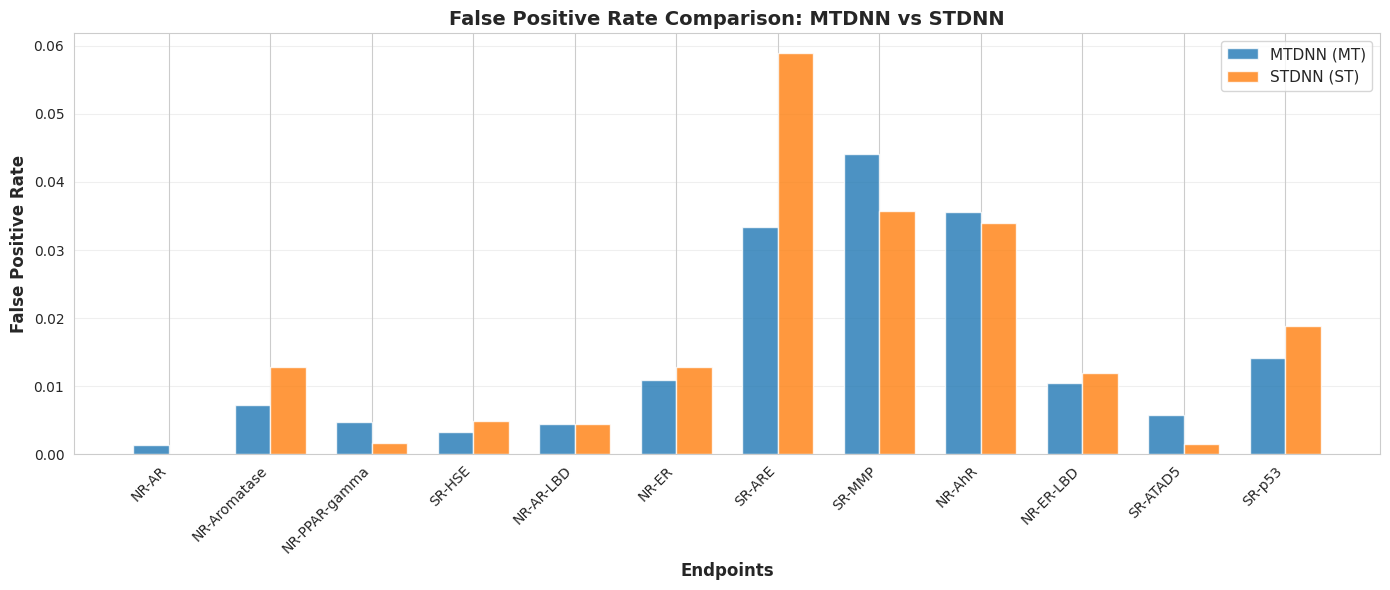

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df['FPMT'], width, label='MTDNN (MT)', alpha=0.8)
bars2 = ax.bar(x + width/2, df['FPST'], width, label='STDNN (ST)', alpha=0.8)

ax.set_xlabel('Endpoints', fontsize=12, fontweight='bold')
ax.set_ylabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('False Positive Rate Comparison: MTDNN vs STDNN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['ENDPOINT'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison of False Positive Rates (FP)

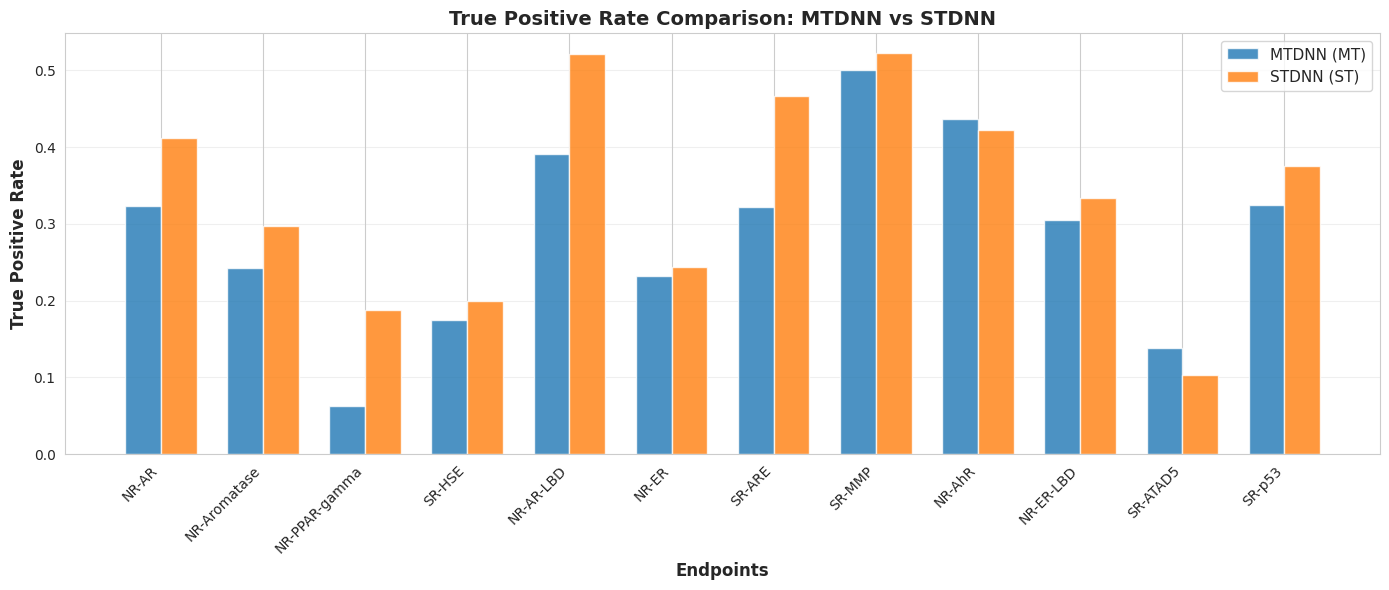

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
width = 0.35

bars1 = ax.bar(x - width/2, df['TPMT'], width, label='MTDNN (MT)', alpha=0.8)
bars2 = ax.bar(x + width/2, df['TPST'], width, label='STDNN (ST)', alpha=0.8)

ax.set_xlabel('Endpoints', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('True Positive Rate Comparison: MTDNN vs STDNN', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['ENDPOINT'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison of True Positive Rates (TP)

In [16]:
# Load the CSV file
df = pd.read_csv('mt_vs_st.csv')
print("Data shape:", df.shape)
print("\nFirst rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Data shape: (12, 9)

First rows:
        ENDPOINT    TPMT    TNMT    FPMT    FNMT    TPST    TNST    FPST  \
0          NR-AR  0.3235  0.9986  0.0014  0.6765  0.4118  1.0000  0.0000   
1   NR-Aromatase  0.2432  0.9927  0.0073  0.7568  0.2973  0.9872  0.0128   
2  NR-PPAR-gamma  0.0625  0.9953  0.0047  0.9375  0.1875  0.9984  0.0016   
3         SR-HSE  0.1750  0.9967  0.0033  0.8250  0.2000  0.9951  0.0049   
4      NR-AR-LBD  0.3913  0.9955  0.0045  0.6087  0.5217  0.9955  0.0045   

     FNST  
0  0.5882  
1  0.7027  
2  0.8125  
3  0.8000  
4  0.4783  

Data types:
ENDPOINT     object
TPMT        float64
TNMT        float64
FPMT        float64
FNMT        float64
TPST        float64
TNST        float64
FPST        float64
FNST        float64
dtype: object

Basic statistics:
            TPMT       TNMT       FPMT       FNMT       TPST       TNST  \
count  12.000000  12.000000  12.000000  12.000000  12.000000  12.000000   
mean    0.287950   0.985367   0.014633   0.712050   0.340467  

# MT vs ST Model Performance Comparison

This notebook visualizes the performance comparison between Multi-Task (MTDNN) and Single-Task (STDNN) models across 12 toxicity endpoints using normalized confusion matrix metrics.